# Phase 7: Model Fine-Tuning

The core sentiment engine is optimized for the code-switched linguistic landscape of the Philippines.

**Input:** `Augmented_Ground_Truth_714.csv` (714 raw rows: 495 authentic + 219 synthetic; 3 corrupted `#NAME?` rows are removed in 7.1)
**Task:** Aspect-level sentiment classification, encoded as a sequence pair: `[CLS] TargetAspect [SEP] Sentence [SEP]`

| Step | What it does |
|---|---|
| 7.1 | Label encoding (Positive=0, Neutral=1, Negative=2), leakage-safe split, tokenization |
| 7.2 | Architectural selection: XLM-RoBERTa-base |
| 7.3 | Baselines: SVM + TF-IDF, Multilingual BERT and VADER |
| 7.4 | Grid search over learning rate x batch size |
| 7.5 | Transfer learning: final fine-tune and test-set comparison of XLM-R against both baselines |

## Setup

**Environment.** Run the next cell once on a fresh machine (then restart the kernel). Tested against `torch>=2.3` (needed for `torch.amp.GradScaler`) and a recent `transformers`; exact versions are written to `phase7_config.json` at the end of the run.

In [5]:
# Run once. Safe to re-run; comment out after the first time.
%pip install -q "torch>=2.3" transformers sentencepiece scikit-learn pandas matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os, gc, json, itertools, random, platform
from importlib import metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup, set_seed)

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

In [7]:
# ---------------- Configuration ----------------
SEED          = 42
DATA_PATH     = 'Augmented_Ground_Truth_714.csv'
OUTPUT_DIR    = 'phase7_outputs'

XLMR_NAME     = 'xlm-roberta-base'
MBERT_NAME    = 'bert-base-multilingual-cased'

# Step 7.4 fixed hyperparameters
EPOCHS        = 5        # fixed
PATIENCE      = 2        # early stopping patience (epochs without val macro-F1 improvement)
WEIGHT_DECAY  = 0.01     # fixed
WARMUP_RATIO  = 0.1
MAX_GRAD_NORM = 1.0
MAX_LEN       = 128

# Step 7.4 grid
LR_GRID       = [2e-5, 3e-5, 5e-5]
BS_GRID       = [16, 32]

# Fair benchmarking: give mBERT the same grid as XLM-R
GRID_FOR_MBERT = True
MBERT_FALLBACK = (2e-5, 16)       # (lr, batch_size) used only if GRID_FOR_MBERT = False

# Final evaluation (Step 7.5): retrain best config with several seeds
FINAL_SEEDS   = [42, 43, 44]

# Class-weighted Cross-Entropy (see note in 7.1). Set False for plain Cross-Entropy.
USE_CLASS_WEIGHTS = True

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.makedirs(OUTPUT_DIR, exist_ok=True)
set_seed(SEED)
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = device.type == 'cuda'          # mixed precision keeps VRAM low
print(f'Using device: {device}  |  mixed precision: {use_amp}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0), f'| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB VRAM')

Using device: cpu  |  mixed precision: False


## Step 7.1: Label Encoding and Tokenization

Sentiment labels are mapped to integers (**Positive = 0, Neutral = 1, Negative = 2**), which PyTorch's Cross-Entropy Loss requires.
The label source is `ground_truth` (4-annotator majority vote, ties already resolved in Phase 6).

In [8]:
label2id = {'POSITIVE': 0, 'NEUTRAL': 1, 'NEGATIVE': 2}
id2label = {v: k for k, v in label2id.items()}
LABEL_NAMES = [id2label[i] for i in range(3)]

df = pd.read_csv(DATA_PATH)
n_raw = len(df)

# Drop corrupted rows: spreadsheet error strings (e.g. '#NAME?') or empty text in `sentence`
# were exported from Excel/Sheets and carry no review content.
EXCEL_ERR = r'^\s*#(?:NAME\?|N/A|REF!|VALUE!|DIV/0!|NULL!|NUM!)\s*$'
txt = df['sentence'].astype(str)
bad = df['sentence'].isna() | txt.str.strip().eq('') | txt.str.match(EXCEL_ERR, case=False)
print(f'Dropping {bad.sum()} corrupted row(s) of {n_raw}:')
print(df.loc[bad, ['place_name', 'TargetAspect', 'sentence', 'sentiment', 'is_synthetic']].to_string())
df = df.loc[~bad].reset_index(drop=True)
assert not df['sentence'].astype(str).str.contains('#NAME?', regex=False).any()
df['ground_truth'] = df['ground_truth'].astype(str).str.strip().str.upper()
df['sentiment']    = df['sentiment'].astype(str).str.strip().str.upper()

assert (df['ground_truth'] == df['sentiment']).all(), 'sentiment and ground_truth disagree'
assert df['ground_truth'].isin(label2id).all(), 'Unresolved ties or invalid labels remain'
assert df[['sentence', 'TargetAspect']].notna().all().all()

df['label'] = df['ground_truth'].map(label2id).astype(int)
print(f'Rows: {len(df)}  |  authentic: {(~df.is_synthetic).sum()}  |  synthetic: {df.is_synthetic.sum()}')
print('\nLabel x origin:')
print(pd.crosstab(df['is_synthetic'].map({False: 'authentic', True: 'synthetic'}), df['ground_truth'])[LABEL_NAMES])

Dropping 3 corrupted row(s) of 714:
                                           place_name              TargetAspect sentence sentiment  is_synthetic
46                                     HYGGE COFFEE 2          Customer Service   #NAME?  NEGATIVE         False
236                             &Matcha - Three Yards  Facilities and Amenities   #NAME?  POSITIVE         False
471  Cafe Gervacios - Pastry and Coffee in Davao City   Ambiance and Atmosphere   #NAME?  POSITIVE         False
Rows: 711  |  authentic: 492  |  synthetic: 219

Label x origin:
ground_truth  POSITIVE  NEUTRAL  NEGATIVE
is_synthetic                             
authentic          407       39        46
synthetic            0        0       219


### Train / Validation / Test split

Three safeguards, because the data is small, imbalanced, and partly synthetic:

1. **Evaluation sets are authentic-only.** Every synthetic row is NEGATIVE, so scoring on them would reward the model for recognising the synthetic style rather than real sentiment. Synthetic rows go to training only.
2. **Duplicate sentences stay together.** The same sentence can appear under several rows (some even under *different* aspects); a plain random split would leak them across train and test. Splits are grouped by normalised **sentence text alone**. This is deliberately stricter than grouping by sentence + aspect: that key would let the same sentence land in train under one aspect and in test under another. Sentence-only grouping keeps every sentence + aspect duplicate together as well, and an explicit assertion below verifies it.
3. **Stratified by sentiment**, so the rare Neutral class appears in every split.

Target is roughly 70 / 15 / 15 of the authentic data, with all synthetic rows added to the training set.

In [9]:
def normalise(text):
    return ' '.join(''.join(ch.lower() if ch.isalnum() else ' ' for ch in str(text)).split())

df['group'] = df['sentence'].map(normalise)
df_auth  = df[~df['is_synthetic']].reset_index(drop=True)
df_synth = df[df['is_synthetic']].reset_index(drop=True)

def hold_out_fold(frame, n_splits, seed):
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rest_idx, fold_idx = next(sgkf.split(frame, frame['label'], frame['group']))
    return frame.iloc[rest_idx].copy(), frame.iloc[fold_idx].copy()

auth_rest,  test_df = hold_out_fold(df_auth,  n_splits=7, seed=SEED)   # ~14% test
auth_train, val_df  = hold_out_fold(auth_rest, n_splits=6, seed=SEED)  # ~14% val

# Synthetic rows whose text also occurs in val/test would leak -> drop them
eval_groups = set(val_df['group']) | set(test_df['group'])
n_before    = len(df_synth)
df_synth    = df_synth[~df_synth['group'].isin(eval_groups)]
print(f'Synthetic rows dropped for leakage: {n_before - len(df_synth)}')

train_df = (pd.concat([auth_train, df_synth], ignore_index=True)
              .sample(frac=1, random_state=SEED).reset_index(drop=True))
val_df, test_df = val_df.reset_index(drop=True), test_df.reset_index(drop=True)

# ---- sanity checks ----
assert not val_df['is_synthetic'].any() and not test_df['is_synthetic'].any()
assert not (set(train_df['group']) & set(val_df['group']))
assert not (set(train_df['group']) & set(test_df['group']))
assert not (set(val_df['group'])   & set(test_df['group']))

# Stronger check at the (sentence, aspect) level, the key a reviewer would test
pair = lambda d: set(zip(d['group'], d['TargetAspect']))
assert not (pair(train_df) & pair(val_df)) and not (pair(train_df) & pair(test_df)) and not (pair(val_df) & pair(test_df))
print('Leakage checks passed: no sentence or (sentence, aspect) pair is shared across train / val / test.')

summary = pd.DataFrame({
    name: d['ground_truth'].value_counts().reindex(LABEL_NAMES).fillna(0).astype(int)
    for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]
}).T
summary['total'] = summary.sum(axis=1)
summary['synthetic'] = [int(d['is_synthetic'].sum()) for d in (train_df, val_df, test_df)]
print(summary)

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    d.drop(columns=['group']).to_csv(os.path.join(OUTPUT_DIR, f'{name}_split.csv'), index=False, encoding='utf-8')

Synthetic rows dropped for leakage: 0
Leakage checks passed: no sentence or (sentence, aspect) pair is shared across train / val / test.
ground_truth  POSITIVE  NEUTRAL  NEGATIVE  total  synthetic
train              290       27       252    569        219
val                 58        6         7     71          0
test                59        6         6     71          0


> **Heads-up on Neutral:** only 39 authentic Neutral rows exist, so the val and test sets contain roughly 5-6 each. Per-class Neutral F1 will be very noisy, and macro-F1 moves in large steps. This is why Step 7.5 reports mean +/- std over multiple seeds rather than a single number.

### Class weighting

The training set is still skewed (Positive-heavy, Neutral-scarce). With `USE_CLASS_WEIGHTS = True` the Cross-Entropy Loss is weighted by inverse class frequency. It is still Cross-Entropy; set the flag to `False` for the unweighted version.

### Tokenization

In [10]:
TOKENIZERS = {
    XLMR_NAME:  AutoTokenizer.from_pretrained(XLMR_NAME),
    MBERT_NAME: AutoTokenizer.from_pretrained(MBERT_NAME),
}

# Show how a code-switched review becomes a padded tensor pair
sample = train_df[train_df['is_synthetic']].iloc[0]
tok = TOKENIZERS[XLMR_NAME]
demo = tok(sample['TargetAspect'], sample['sentence'], truncation=True, max_length=MAX_LEN,
           padding='max_length', return_tensors='pt')
print('Aspect  :', sample['TargetAspect'])
print('Sentence:', sample['sentence'])
print('Tokens  :', tok.convert_ids_to_tokens(demo['input_ids'][0][:demo['attention_mask'][0].sum()]))
print('Tensor shapes:', {k: tuple(v.shape) for k, v in demo.items()})

# Check MAX_LEN is not truncating anything
lens = [len(x) for x in tok(train_df['TargetAspect'].tolist(), train_df['sentence'].tolist())['input_ids']]
print(f'\nToken length (XLM-R): mean={np.mean(lens):.1f}  p99={np.percentile(lens, 99):.0f}  max={max(lens)}  | MAX_LEN={MAX_LEN}')

c:\Users\User\Downloads\Thesis Files\.venv-1\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Aspect  : Facilities and Amenities
Sentence: Sakit sa likod ilang mga bangko, not for long hours.
Tokens  : ['<s>', '▁Faci', 'li', 'ties', '▁and', '▁Amen', 'ities', '</s>', '</s>', '▁Sakit', '▁sa', '▁likod', '▁ilang', '▁mga', '▁bang', 'ko', ',', '▁not', '▁for', '▁long', '▁hours', '.', '</s>']
Tensor shapes: {'input_ids': (1, 128), 'attention_mask': (1, 128)}

Token length (XLM-R): mean=25.8  p99=53  max=69  | MAX_LEN=128


In [11]:
class ABSADataset(Dataset):
    """Aspect-sentence pair encoding. Padding is applied per batch by the collator."""
    def __init__(self, frame, tokenizer, max_len=MAX_LEN):
        self.enc = tokenizer(frame['TargetAspect'].astype(str).tolist(),
                             frame['sentence'].astype(str).tolist(),
                             truncation=True, max_length=max_len)
        self.labels = frame['label'].tolist()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]
        return item

def make_collate(tokenizer):
    def collate(batch):
        labels = torch.tensor([b.pop('labels') for b in batch], dtype=torch.long)
        out = tokenizer.pad(batch, return_tensors='pt')
        out['labels'] = labels
        return out
    return collate

## Step 7.2: Architectural Selection

The research uses the **XLM-RoBERTa-base** architecture via Hugging Face Transformers. It is selected over mBERT for its stronger performance on informal web-scraped text and its pre-training on a 2.5 TB CommonCrawl corpus that includes Cebuano and Tagalog.

In [12]:
_m = AutoModelForSequenceClassification.from_pretrained(
        XLMR_NAME, num_labels=3, id2label=id2label, label2id=label2id)
n_params = sum(p.numel() for p in _m.parameters())
print(f'{XLMR_NAME}: {n_params/1e6:.0f}M parameters | layers={_m.config.num_hidden_layers} '
      f'| hidden={_m.config.hidden_size} | vocab={_m.config.vocab_size}')
print('Classification head:', _m.classifier)
del _m; gc.collect()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 401.75it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


xlm-roberta-base: 278M parameters | layers=12 | hidden=768 | vocab=250002
Classification head: XLMRobertaClassificationHead(
  (dense): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (out_proj): Linear(in_features=768, out_features=3, bias=True)
)


83

## Shared Training Utilities

One engine fine-tunes both transformers, so XLM-R and mBERT are treated identically (same split, loss, schedule, early stopping).

- **Loss:** Cross-Entropy (optionally class-weighted)
- **Optimizer:** AdamW, weight decay 0.01 (not applied to bias / LayerNorm), linear warmup then linear decay, gradient clipping at 1.0
- **Early stopping:** monitors validation macro-F1 (accuracy would be dominated by Positive), validation loss breaks ties, patience 2
- **Checkpointing:** the best-epoch weights are restored at the end

In [13]:
def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    per_class = f1_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
    return {
        'accuracy':    accuracy_score(y_true, y_pred),
        'macro_f1':    f1_score(y_true, y_pred, labels=[0, 1, 2], average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, labels=[0, 1, 2], average='weighted', zero_division=0),
        'f1_positive': per_class[0], 'f1_neutral': per_class[1], 'f1_negative': per_class[2],
    }

def class_weights_from(frame):
    counts = np.bincount(frame['label'], minlength=3).astype(float)
    return torch.tensor(counts.sum() / (3.0 * np.maximum(counts, 1)), dtype=torch.float)

@torch.no_grad()
def predict(model, loader, loss_fn=None):
    model.eval()
    all_logits, all_labels = [], []
    total_loss, n = 0.0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(**batch).logits
        logits = logits.float()
        if loss_fn is not None:
            total_loss += loss_fn(logits, labels).item() * len(labels)
            n += len(labels)
        all_logits.append(logits.cpu()); all_labels.append(labels.cpu())
    logits = torch.cat(all_logits)
    return {'loss': total_loss / max(n, 1), 'preds': logits.argmax(-1).numpy(),
            'labels': torch.cat(all_labels).numpy(), 'probs': torch.softmax(logits, -1).numpy()}

def fine_tune(model_name, train_frame, val_frame, lr, batch_size, seed,
              epochs=EPOCHS, patience=PATIENCE, keep_model=False, verbose=False):
    set_seed(seed)
    tokenizer = TOKENIZERS[model_name]
    collate   = make_collate(tokenizer)
    gen = torch.Generator(); gen.manual_seed(seed)
    train_loader = DataLoader(ABSADataset(train_frame, tokenizer), batch_size=batch_size,
                              shuffle=True, collate_fn=collate, generator=gen)
    val_loader   = DataLoader(ABSADataset(val_frame, tokenizer), batch_size=64,
                              shuffle=False, collate_fn=collate)

    model = AutoModelForSequenceClassification.from_pretrained(
                model_name, num_labels=3, id2label=id2label, label2id=label2id).to(device)

    no_decay = ('bias', 'LayerNorm.weight')
    optimizer = AdamW([
        {'params': [p for n, p in model.named_parameters() if not any(k in n for k in no_decay)],
         'weight_decay': WEIGHT_DECAY},
        {'params': [p for n, p in model.named_parameters() if any(k in n for k in no_decay)],
         'weight_decay': 0.0},
    ], lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(WARMUP_RATIO * total_steps), total_steps)
    scaler = torch.amp.GradScaler(device.type, enabled=use_amp)

    weight  = class_weights_from(train_frame).to(device) if USE_CLASS_WEIGHTS else None
    loss_fn = nn.CrossEntropyLoss(weight=weight)

    history, best = [], {'macro_f1': -1.0, 'val_loss': float('inf'), 'epoch': 0}
    best_state, stale = None, 0

    for epoch in range(1, epochs + 1):
        model.train()
        running, seen = 0.0, 0
        for batch in tqdm(train_loader, desc=f'epoch {epoch}/{epochs}', leave=False, disable=not verbose):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                logits = model(**batch).logits
            loss = loss_fn(logits.float(), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            running += loss.item() * len(labels); seen += len(labels)

        out = predict(model, val_loader, loss_fn)
        m = compute_metrics(out['labels'], out['preds'])
        history.append({'epoch': epoch, 'train_loss': running / seen, 'val_loss': out['loss'],
                        'val_accuracy': m['accuracy'], 'val_macro_f1': m['macro_f1']})
        if verbose:
            print(f"epoch {epoch}: train_loss={running/seen:.4f} val_loss={out['loss']:.4f} "
                  f"val_acc={m['accuracy']:.3f} val_macro_f1={m['macro_f1']:.3f}")

        improved = (m['macro_f1'] > best['macro_f1'] + 1e-9) or \
                   (abs(m['macro_f1'] - best['macro_f1']) <= 1e-9 and out['loss'] < best['val_loss'])
        if improved:
            best = {'macro_f1': m['macro_f1'], 'val_loss': out['loss'], 'epoch': epoch,
                    'accuracy': m['accuracy']}
            stale = 0
            if keep_model:
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= patience:
                if verbose: print(f'Early stopping at epoch {epoch} (best epoch {best["epoch"]})')
                break

    result = {'history': pd.DataFrame(history), 'best': best, 'epochs_run': len(history)}
    if keep_model:
        model.load_state_dict(best_state)
        result['model'] = model
    else:
        del model
    del optimizer, scheduler
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    return result

## Step 7.3: Baseline Selection

XLM-R is benchmarked against two standard baselines from the related literature:

1. **SVM + TF-IDF** - the traditional machine-learning baseline (framework of Suciati and Budi). Word 1-2-gram TF-IDF on the sentence, plus the target aspect one-hot encoded so it sees the same information as the transformers. `C` is tuned on the validation set.
2. **Multilingual BERT (mBERT)** - the primary transformer baseline (methodology of Maceda et al.), run through the same engine and grid as XLM-R in Steps 7.4 and 7.5.

In [14]:
def build_svm(C):
    pre = ColumnTransformer([
        ('sentence', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True), 'sentence'),
        ('aspect',   OneHotEncoder(handle_unknown='ignore'), ['TargetAspect']),
    ])
    clf = LinearSVC(C=C, class_weight='balanced' if USE_CLASS_WEIGHTS else None,
                    random_state=SEED, max_iter=20000)
    return Pipeline([('pre', pre), ('clf', clf)])

svm_rows = []
for C in [0.1, 0.5, 1, 5, 10]:
    pipe = build_svm(C).fit(train_df[['sentence', 'TargetAspect']], train_df['label'])
    pv = pipe.predict(val_df[['sentence', 'TargetAspect']])
    m = compute_metrics(val_df['label'], pv)
    svm_rows.append({'C': C, 'val_accuracy': m['accuracy'], 'val_macro_f1': m['macro_f1']})
svm_grid = pd.DataFrame(svm_rows)
print(svm_grid.round(4).to_string(index=False))

best_C = svm_grid.sort_values(['val_macro_f1', 'val_accuracy'], ascending=False).iloc[0]['C']
svm_final = build_svm(best_C).fit(train_df[['sentence', 'TargetAspect']], train_df['label'])
svm_test_pred = svm_final.predict(test_df[['sentence', 'TargetAspect']])
svm_test_metrics = compute_metrics(test_df['label'], svm_test_pred)
print(f'\nBest C = {best_C}')
print('SVM + TF-IDF test metrics:', {k: round(v, 4) for k, v in svm_test_metrics.items()})

   C  val_accuracy  val_macro_f1
 0.1        0.7887        0.2963
 0.5        0.8169        0.3021
 1.0        0.8310        0.3878
 5.0        0.8310        0.3878
10.0        0.8310        0.3878

Best C = 1.0
SVM + TF-IDF test metrics: {'accuracy': 0.7887, 'macro_f1': 0.2963, 'weighted_f1': 0.7387, 'f1_positive': np.float64(0.8889), 'f1_neutral': np.float64(0.0), 'f1_negative': np.float64(0.0)}


## Step 7.4: Hyperparameter Tuning Strategy

Optimizing XLM-R means balancing convergence speed against the risk of catastrophic forgetting. A **grid search** is run over a constrained space:

| Hyperparameter | Value |
|---|---|
| Epochs | 5 (fixed), early stopping patience = 2 |
| Weight decay | 0.01 (fixed) |
| Learning rate | {2e-5, 3e-5, 5e-5} |
| Batch size | {16, 32} |

That is 6 configurations per model. Configurations are ranked by **validation** macro-F1 only; the test set is not touched until Step 7.5.

In [15]:
GRID_HISTORIES = {}   # (model, lr, bs) -> per-epoch DataFrame

def run_grid(model_name):
    rows = []
    combos = list(itertools.product(LR_GRID, BS_GRID))
    for lr, bs in tqdm(combos, desc=f'grid: {model_name}'):
        res = fine_tune(model_name, train_df, val_df, lr, bs, seed=SEED)
        GRID_HISTORIES[(model_name, lr, bs)] = res['history']
        rows.append({'model': model_name, 'learning_rate': lr, 'batch_size': bs,
                     'best_epoch': res['best']['epoch'], 'epochs_run': res['epochs_run'],
                     'val_macro_f1': res['best']['macro_f1'], 'val_accuracy': res['best']['accuracy'],
                     'val_loss': res['best']['val_loss']})
    return pd.DataFrame(rows)

def pick_best(grid):
    return grid.sort_values(['val_macro_f1', 'val_loss'], ascending=[False, True]).iloc[0]

grid_xlmr = run_grid(XLMR_NAME)
print(grid_xlmr.round(4).to_string(index=False))
best_xlmr = pick_best(grid_xlmr)
print(f"\nBest XLM-R config -> lr={best_xlmr['learning_rate']}, batch_size={int(best_xlmr['batch_size'])}, "
      f"val macro-F1={best_xlmr['val_macro_f1']:.4f}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1711.55it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|███

           model  learning_rate  batch_size  best_epoch  epochs_run  val_macro_f1  val_accuracy  val_loss
xlm-roberta-base            0.0          16           3           5        0.5068        0.8451    0.9697
xlm-roberta-base            0.0          32           4           5        0.4111        0.8169    0.9179
xlm-roberta-base            0.0          16           3           5        0.4756        0.8451    1.0529
xlm-roberta-base            0.0          32           5           5        0.3978        0.7887    0.9562
xlm-roberta-base            0.0          16           5           5        0.6414        0.8732    1.4324
xlm-roberta-base            0.0          32           3           5        0.4709        0.7746    1.1208

Best XLM-R config -> lr=5e-05, batch_size=16, val macro-F1=0.6414


In [16]:
if GRID_FOR_MBERT:
    grid_mbert = run_grid(MBERT_NAME)
    print(grid_mbert.round(4).to_string(index=False))
    best_mbert = pick_best(grid_mbert)
    mbert_cfg = (float(best_mbert['learning_rate']), int(best_mbert['batch_size']))
else:
    grid_mbert = pd.DataFrame()
    mbert_cfg = MBERT_FALLBACK
xlmr_cfg = (float(best_xlmr['learning_rate']), int(best_xlmr['batch_size']))
print(f'\nXLM-R config: lr={xlmr_cfg[0]}, bs={xlmr_cfg[1]}   |   mBERT config: lr={mbert_cfg[0]}, bs={mbert_cfg[1]}')

pd.concat([grid_xlmr, grid_mbert], ignore_index=True).to_csv(
    os.path.join(OUTPUT_DIR, 'grid_search_results.csv'), index=False)

grid: bert-base-multilingual-cased:   0%|          | 0/6 [00:00<?, ?it/s]c:\Users\User\Downloads\Thesis Files\.venv-1\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1697.

                       model  learning_rate  batch_size  best_epoch  epochs_run  val_macro_f1  val_accuracy  val_loss
bert-base-multilingual-cased            0.0          16           3           5        0.4669        0.7606    0.9172
bert-base-multilingual-cased            0.0          32           4           5        0.6045        0.7606    0.7912
bert-base-multilingual-cased            0.0          16           3           5        0.5753        0.8169    1.0253
bert-base-multilingual-cased            0.0          32           5           5        0.4201        0.8310    1.1284
bert-base-multilingual-cased            0.0          16           3           5        0.4944        0.8310    1.0911
bert-base-multilingual-cased            0.0          32           4           5        0.3944        0.8028    1.2921

XLM-R config: lr=5e-05, bs=16   |   mBERT config: lr=2e-05, bs=32


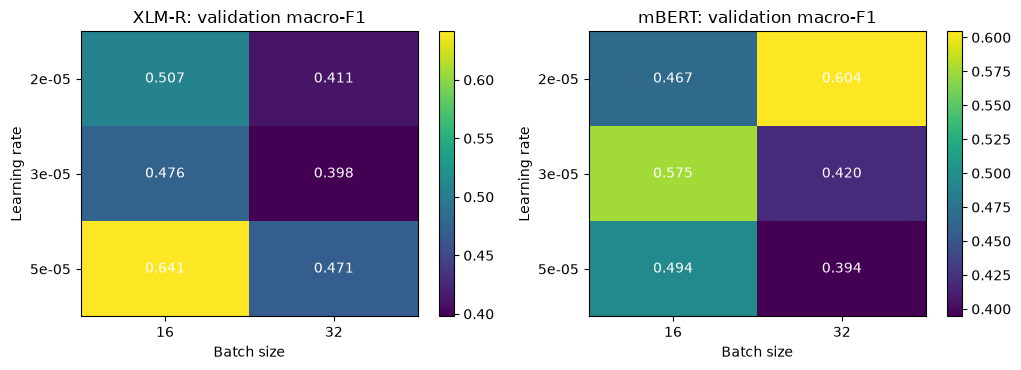

In [17]:
# Validation macro-F1 heatmaps (learning rate x batch size)
grids = [('XLM-R', grid_xlmr)] + ([('mBERT', grid_mbert)] if len(grid_mbert) else [])
fig, axes = plt.subplots(1, len(grids), figsize=(5.2 * len(grids), 3.8), squeeze=False)
for ax, (name, g) in zip(axes[0], grids):
    piv = g.pivot(index='learning_rate', columns='batch_size', values='val_macro_f1')
    im = ax.imshow(piv.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(piv.columns)), piv.columns); ax.set_yticks(range(len(piv.index)), [f'{v:.0e}' for v in piv.index])
    ax.set_xlabel('Batch size'); ax.set_ylabel('Learning rate'); ax.set_title(f'{name}: validation macro-F1')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f'{piv.values[i, j]:.3f}', ha='center', va='center', color='white', fontsize=10)
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'grid_search_heatmap.png'), dpi=200)
plt.show()

## Step 7.5: Transfer Learning

The best configuration for each transformer is re-trained from the pre-trained checkpoint on the training set (authentic + synthetic), with the validation set used only for early stopping. Each model is trained with several seeds because the validation and test sets are small; the first seed's model is kept as the final model and saved to disk.

The test set is used here for the first time.

In [18]:
FINAL_NAME = {XLMR_NAME: 'XLM-RoBERTa', MBERT_NAME: 'mBERT'}
test_loaders = {n: DataLoader(ABSADataset(test_df, TOKENIZERS[n]), batch_size=64, shuffle=False,
                              collate_fn=make_collate(TOKENIZERS[n])) for n in FINAL_NAME}
test_eval_loss = nn.CrossEntropyLoss(weight=class_weights_from(train_df).to(device) if USE_CLASS_WEIGHTS else None)

final_runs, final_preds, final_histories = [], {}, {}
for model_name, (lr, bs) in [(XLMR_NAME, xlmr_cfg), (MBERT_NAME, mbert_cfg)]:
    for seed in FINAL_SEEDS:
        print(f'>>> {FINAL_NAME[model_name]} | lr={lr} bs={bs} seed={seed}')
        res = fine_tune(model_name, train_df, val_df, lr, bs, seed=seed, keep_model=True, verbose=True)
        out = predict(res['model'], test_loaders[model_name], test_eval_loss)
        m = compute_metrics(out['labels'], out['preds'])
        final_runs.append({'model': FINAL_NAME[model_name], 'seed': seed, 'lr': lr, 'batch_size': bs,
                           'best_epoch': res['best']['epoch'], 'val_macro_f1': res['best']['macro_f1'],
                           'test_loss': out['loss'], **{f'test_{k}': v for k, v in m.items()}})
        final_preds[(FINAL_NAME[model_name], seed)] = out['preds']
        if seed == FINAL_SEEDS[0]:
            final_histories[FINAL_NAME[model_name]] = res['history']
            if model_name == XLMR_NAME:   # keep the final sentiment engine
                save_dir = os.path.join(OUTPUT_DIR, 'xlmr_absa_final')
                res['model'].save_pretrained(save_dir); TOKENIZERS[model_name].save_pretrained(save_dir)
                print(f'Saved final XLM-R model to {save_dir}')
        del res['model']; gc.collect()
        if device.type == 'cuda': torch.cuda.empty_cache()

final_df = pd.DataFrame(final_runs)
final_df.to_csv(os.path.join(OUTPUT_DIR, 'final_runs_per_seed.csv'), index=False)
final_df.round(4)

>>> XLM-RoBERTa | lr=5e-05 bs=16 seed=42


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 400.38it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1: train_loss=0.9999 val_loss=0.8698 val_acc=0.507 val_macro_f1=0.294


epoch 2: train_loss=0.7072 val_loss=1.1797 val_acc=0.845 val_macro_f1=0.455


epoch 3: train_loss=0.5744 val_loss=0.9708 val_acc=0.789 val_macro_f1=0.513


...

epoch 2: train_loss=0.8569 val_loss=0.9408 val_acc=0.746 val_macro_f1=0.336


epoch 3: train_loss=0.5766 val_loss=0.9121 val_acc=0.775 val_macro_f1=0.351


epoch 4: train_loss=0.4860 val_loss=0.7915 val_acc=0.746 val_macro_f1=0.366


epoch 5: train_loss=0.3985 val_loss=0.8615 val_acc=0.775 val_macro_f1=0.383


,model,seed,lr,batch_size,best_epoch,val_macro_f1,test_loss,test_accuracy,test_macro_f1,test_weighted_f1,test_f1_positive,test_f1_neutral,test_f1_negative
0,XLM-RoBERTa,42,0.0,16,5,0.6414,2.0003,0.8028,0.3593,0.7599,0.8960,0.0000,0.1818
1,XLM-RoBERTa,43,0.0,16,4,0.4544,1.5983,0.7042,0.4062,0.7208,0.8276,0.2857,0.1053
2,XLM-RoBERTa,44,0.0,16,3,0.5265,1.3411,0.6620,0.3643,0.6842,0.7928,0.0000,0.3000
3,mBERT,42,0.0,32,4,0.6045,1.2473,0.4507,0.2305,0.5307,0.6327,0.0588,0.0000
4,mBERT,43,0.0,32,4,0.4965,1.2734,0.5915,0.2793,0.6429,0.7664,0.0714,0.0000
5,mBERT,44,0.0,32,5,0.3828,1.1458,0.7465,0.3309,0.7255,0.8595,0.1333,0.0000


### Benchmark results (test set, authentic-only)

In [19]:
y_test = test_df['label'].values
metric_cols = ['test_accuracy', 'test_macro_f1', 'test_weighted_f1', 'test_f1_positive', 'test_f1_neutral', 'test_f1_negative']

rows = []
for name, g in final_df.groupby('model', sort=False):
    row = {'Model': name}
    for c in metric_cols:
        row[c.replace('test_', '')] = f'{g[c].mean():.3f} +/- {g[c].std(ddof=0):.3f}'
    rows.append(row)
rows.append({'Model': 'SVM + TF-IDF', **{c.replace('test_', ''): f'{svm_test_metrics[c.replace("test_", "")]:.3f}' for c in metric_cols}})
results_table = pd.DataFrame(rows)
print(f'Transformers: mean +/- std over seeds {FINAL_SEEDS}; SVM is deterministic.  Test n = {len(test_df)}')
results_table

Transformers: mean +/- std over seeds [42, 43, 44]; SVM is deterministic.  Test n = 71


,Model,accuracy,macro_f1,weighted_f1,f1_positive,f1_neutral,f1_negative
0,XLM-RoBERTa,0.723 +/- 0.059,0.377 +/- 0.021,0.722 +/- 0.031,0.839 +/- 0.043,0.095 +/- 0.135,0.196 +/- 0.080
1,mBERT,0.596 +/- 0.121,0.280 +/- 0.041,0.633 +/- 0.080,0.753 +/- 0.093,0.088 +/- 0.033,0.000 +/- 0.000
2,SVM + TF-IDF,0.789,0.296,0.739,0.889,0.000,0.000


XLM-RoBERTa (final model) classification report:
              precision    recall  f1-score   support

    POSITIVE      0.848     0.949     0.896        59
     NEUTRAL      0.000     0.000     0.000         6
    NEGATIVE      0.200     0.167     0.182         6

    accuracy                          0.803        71
   macro avg      0.349     0.372     0.359        71
weighted avg      0.722     0.803     0.760        71



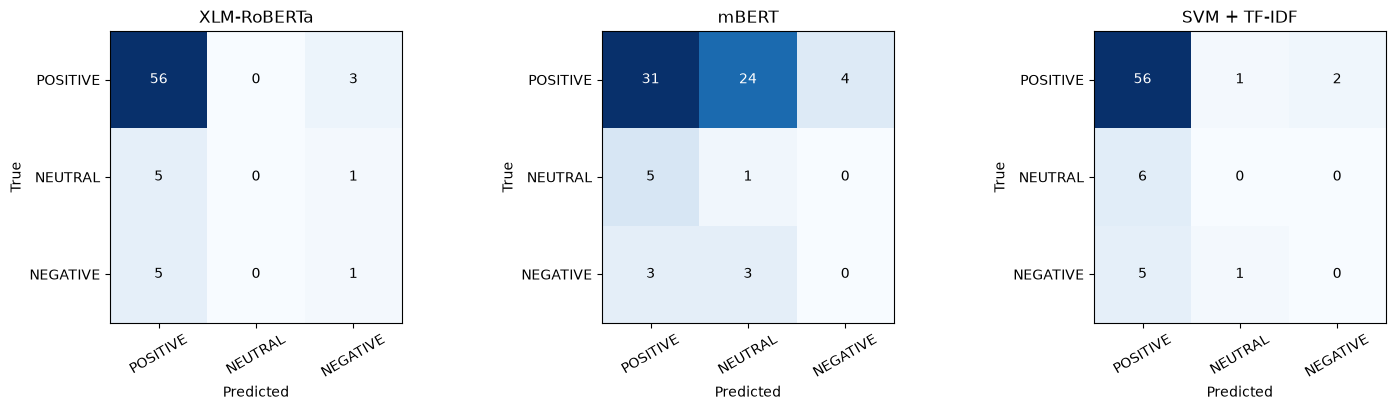

In [20]:
# Per-class report and confusion matrices (first seed = final model)
s0 = FINAL_SEEDS[0]
xlmr_p = final_preds[('XLM-RoBERTa', s0)] 
pred_sets = {'XLM-RoBERTa': final_preds[('XLM-RoBERTa', s0)],
             'mBERT': final_preds[('mBERT', s0)],
             'SVM + TF-IDF': svm_test_pred}

print('XLM-RoBERTa (final model) classification report:')
print(classification_report(y_test, pred_sets['XLM-RoBERTa'], labels=[0, 1, 2],
                            target_names=LABEL_NAMES, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, p) in zip(axes, pred_sets.items()):
    cm = confusion_matrix(y_test, p, labels=[0, 1, 2])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3), LABEL_NAMES, rotation=30); ax.set_yticks(range(3), LABEL_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(name)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=200)
plt.show()

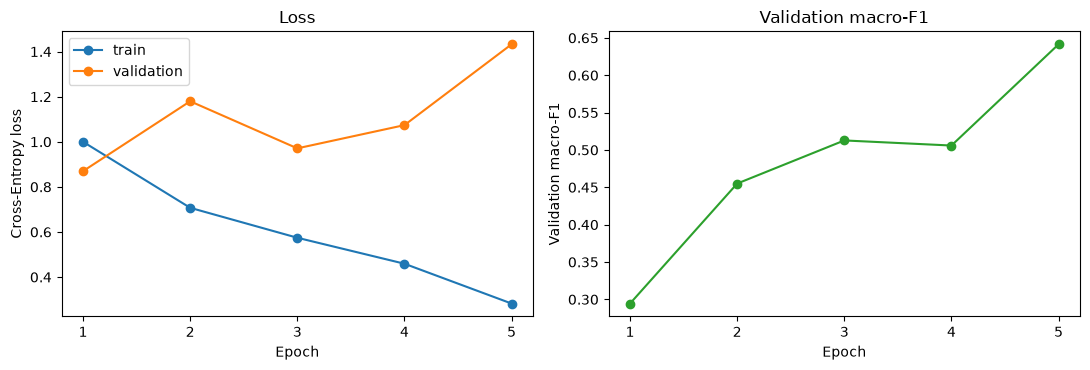

In [21]:
# Training curves of the final XLM-R model (seed 1)
h = final_histories['XLM-RoBERTa']
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(h['epoch'], h['train_loss'], marker='o', label='train'); ax[0].plot(h['epoch'], h['val_loss'], marker='o', label='validation')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Cross-Entropy loss'); ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(h['epoch'], h['val_macro_f1'], marker='o', color='tab:green')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Validation macro-F1'); ax[1].set_title('Validation macro-F1')
for a in ax: a.set_xticks(h['epoch'])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'xlmr_training_curves.png'), dpi=200)
plt.show()

In [22]:
# ---- Save everything needed for the manuscript ----
test_out = test_df[['place_name', 'shop_type', 'TargetAspect', 'sentence', 'ground_truth']].copy()
test_out['pred_xlmr'] = [id2label[i] for i in xlmr_p]
test_out['pred_mbert'] = [id2label[i] for i in pred_sets['mBERT']]
test_out['pred_svm'] = [id2label[i] for i in svm_test_pred]
test_out.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False, encoding='utf-8')
results_table.to_csv(os.path.join(OUTPUT_DIR, 'benchmark_results.csv'), index=False)

with open(os.path.join(OUTPUT_DIR, 'phase7_config.json'), 'w') as f:
    json.dump({'label2id': label2id, 'seed': SEED, 'epochs': EPOCHS, 'patience': PATIENCE,
               'weight_decay': WEIGHT_DECAY, 'lr_grid': LR_GRID, 'bs_grid': BS_GRID,
               'xlmr_best': {'lr': xlmr_cfg[0], 'batch_size': xlmr_cfg[1]},
               'mbert_best': {'lr': mbert_cfg[0], 'batch_size': mbert_cfg[1]},
               'class_weighted_loss': USE_CLASS_WEIGHTS, 'final_seeds': FINAL_SEEDS,
               'split_sizes': {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)},
               'rows_dropped_corrupted': int(bad.sum()),
               'environment': {'python': platform.python_version(), 'device': str(device.type),
                               **{p: metadata.version(p) for p in
                                  ['torch', 'transformers', 'scikit-learn', 'pandas', 'numpy']}}}, f, indent=2)
print('Saved outputs to', os.path.abspath(OUTPUT_DIR))
print(sorted(os.listdir(OUTPUT_DIR)))

Saved outputs to c:\Users\User\Downloads\Thesis Files\.venv-1\phase7_outputs
['benchmark_results.csv', 'confusion_matrices.png', 'final_runs_per_seed.csv', 'grid_search_heatmap.png', 'grid_search_results.csv', 'phase7_config.json', 'test_predictions.csv', 'test_split.csv', 'train_split.csv', 'val_split.csv', 'xlmr_absa_final', 'xlmr_training_curves.png']


Device: cpu
Loading model from phase7_outputs\xlmr_absa_final ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 690.91it/s]


Model ready.

================= EXTERNAL VALIDATION: Validation_Set_15.csv (n=3459) =================
Predicted-label distribution:
pred_label
POSITIVE    2538
NEUTRAL      283
NEGATIVE     638
Mean confidence  : 0.912
Median confidence: 0.962

Metrics:
  accuracy    : 0.7392
  macro_f1    : 0.4745
  weighted_f1 : 0.7539
  f1_positive : 0.8639
  f1_neutral  : 0.1225
  f1_negative : 0.4371

Classification report:
              precision    recall  f1-score   support

    POSITIVE      0.903     0.828     0.864      2768
     NEUTRAL      0.120     0.125     0.123       272
    NEGATIVE      0.362     0.551     0.437       419

    accuracy                          0.739      3459
   macro avg      0.462     0.501     0.475      3459
weighted avg      0.776     0.739     0.754      3459


================= EXTERNAL TEST: Test_Set_15.csv (n=3459) =================
Predicted-label distribution:
pred_label
POSITIVE    2571
NEUTRAL      228
NEGATIVE     660
Mean confidence  : 0.914
Median co

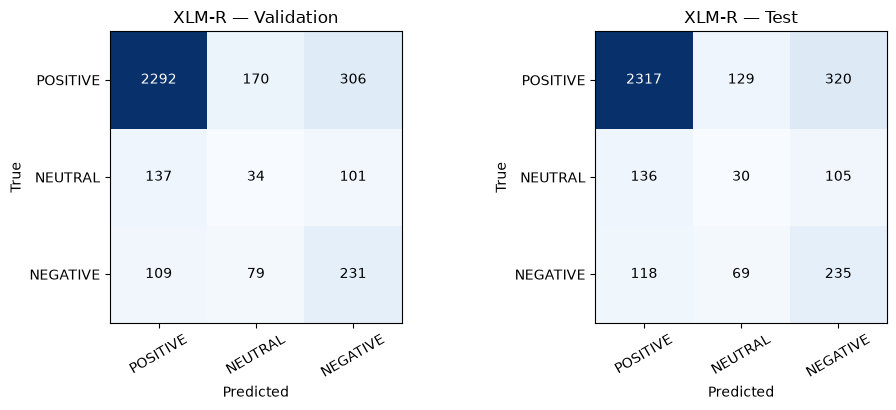

Saved figure to phase7_outputs\external_confusion_matrices.png

Saved predictions to c:\Users\User\Downloads\Thesis Files\.venv-1\phase7_outputs


In [7]:
# =============================================================================
# External eval: Validation_Set_15.csv FIRST, then Test_Set_15.csv LAST
# Uses saved XLM-R from phase7_outputs/xlmr_absa_final. Fully standalone.
# Prints report + confusion matrix if a 'ground_truth' column is present.
# =============================================================================
import os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

VAL_EXT_PATH  = 'Validation_Set_15.csv'
TEST_EXT_PATH = 'Test_Set_15.csv'
OUTPUT_DIR    = globals().get('OUTPUT_DIR', 'phase7_outputs')
MODEL_DIR     = os.path.join(OUTPUT_DIR, 'xlmr_absa_final')
MAX_LEN       = 128

label2id    = {'POSITIVE': 0, 'NEUTRAL': 1, 'NEGATIVE': 2}
id2label    = {v: k for k, v in label2id.items()}
LABEL_NAMES = [id2label[i] for i in range(3)]

device  = globals().get('device', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
use_amp = (device.type == 'cuda')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

assert os.path.isdir(MODEL_DIR), f'Missing saved model: {MODEL_DIR}'
print(f'Device: {device}\nLoading model from {MODEL_DIR} ...')
tokenizer_ext = AutoTokenizer.from_pretrained(MODEL_DIR)
model_ext     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model_ext.eval()
print('Model ready.')

class ABSADataset(Dataset):
    def __init__(self, frame, tokenizer, max_len=MAX_LEN):
        self.enc = tokenizer(frame['TargetAspect'].astype(str).tolist(),
                             frame['sentence'].astype(str).tolist(),
                             truncation=True, max_length=max_len)
        self.labels = frame['label'].tolist() if 'label' in frame.columns else [0]*len(frame)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]
        return item

def make_collate(tok):
    def collate(batch):
        labels = torch.tensor([b.pop('labels') for b in batch], dtype=torch.long)
        out    = tok.pad(batch, return_tensors='pt')
        out['labels'] = labels
        return out
    return collate

@torch.no_grad()
def predict(model, loader):
    model.eval()
    L = []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        batch.pop('labels', None)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            logits = model(**batch).logits
        L.append(logits.float().cpu())
    logits = torch.cat(L)
    probs  = torch.softmax(logits, -1).numpy()
    return probs.argmax(-1), probs

def compute_metrics(y_true, y_pred):
    per = f1_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    return {'accuracy':    accuracy_score(y_true, y_pred),
            'macro_f1':    f1_score(y_true, y_pred, labels=[0,1,2], average='macro',    zero_division=0),
            'weighted_f1': f1_score(y_true, y_pred, labels=[0,1,2], average='weighted', zero_division=0),
            'f1_positive': per[0], 'f1_neutral': per[1], 'f1_negative': per[2]}

def run_external(csv_path, tag):
    df = pd.read_csv(csv_path)
    df['TargetAspect'] = df['TargetAspect'].astype(str)
    df['sentence']     = df['sentence'].astype(str)

    has_gold = 'ground_truth' in df.columns
    if has_gold:
        df['ground_truth'] = df['ground_truth'].astype(str).str.strip().str.upper()
        df['label']        = df['ground_truth'].map(label2id)
        if df['label'].isna().any():
            raise ValueError(f'{csv_path}: unrecognised ground_truth values')
        df['label'] = df['label'].astype(int)

    loader = DataLoader(ABSADataset(df, tokenizer_ext), batch_size=64, shuffle=False,
                        collate_fn=make_collate(tokenizer_ext))
    preds, probs = predict(model_ext, loader)

    df['pred_label'] = [id2label[i] for i in preds]
    df['pred_conf']  = probs.max(axis=1)
    for i in range(3):
        df[f'prob_{id2label[i]}'] = probs[:, i]

    print(f'\n================= {tag}: {csv_path} (n={len(df)}) =================')
    dist = (df['pred_label'].value_counts().reindex(LABEL_NAMES).fillna(0).astype(int))
    print('Predicted-label distribution:')
    print(dist.to_string())
    print(f'Mean confidence  : {df["pred_conf"].mean():.3f}')
    print(f'Median confidence: {df["pred_conf"].median():.3f}')

    cm = None
    if has_gold:
        y_true = df['label'].values
        m = compute_metrics(y_true, preds)
        print('\nMetrics:')
        for k, v in m.items(): print(f'  {k:<12}: {v:.4f}')
        print('\nClassification report:')
        print(classification_report(y_true, preds, labels=[0,1,2],
                                    target_names=LABEL_NAMES, digits=3, zero_division=0))
        cm = confusion_matrix(y_true, preds, labels=[0,1,2])
    else:
        print('\n[No ground_truth column -> metrics/confusion matrix skipped]')

    return df, cm

# ---------- Run: validation first, test last ----------
val_ext,  val_cm  = run_external(VAL_EXT_PATH,  'EXTERNAL VALIDATION')
test_ext, test_cm = run_external(TEST_EXT_PATH, 'EXTERNAL TEST')

# ---------- Confusion matrices (only if labels existed) ----------
panels = []
if val_cm  is not None: panels.append(('Validation', val_cm))
if test_cm is not None: panels.append(('Test',       test_cm))
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(5*len(panels), 4.2), squeeze=False)
    for ax, (name, cm) in zip(axes[0], panels):
        ax.imshow(cm, cmap='Blues')
        ax.set_xticks(range(3), LABEL_NAMES, rotation=30)
        ax.set_yticks(range(3), LABEL_NAMES)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'XLM-R — {name}')
        for i in range(3):
            for j in range(3):
                ax.text(j, i, cm[i,j], ha='center', va='center',
                        color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.tight_layout()
    out_png = os.path.join(OUTPUT_DIR, 'external_confusion_matrices.png')
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f'Saved figure to {out_png}')

# ---------- Save predictions ----------
val_ext.to_csv( os.path.join(OUTPUT_DIR, 'external_validation_predictions.csv'),
                index=False, encoding='utf-8')
test_ext.to_csv(os.path.join(OUTPUT_DIR, 'external_test_predictions.csv'),
                index=False, encoding='utf-8')
print(f'\nSaved predictions to {os.path.abspath(OUTPUT_DIR)}')

del model_ext; gc.collect()
if device.type == 'cuda': torch.cuda.empty_cache()

In [6]:
import pandas as pd

def star_to_label(r):
    r = int(r)
    if r <= 2:  return 'NEGATIVE'
    if r == 3:  return 'NEUTRAL'
    return 'POSITIVE'

for path in ['Validation_Set_15.csv', 'Test_Set_15.csv']:
    df = pd.read_csv(path)
    df['ground_truth'] = df['rating'].apply(star_to_label)
    df.to_csv(path, index=False, encoding='utf-8')
    print(f'{path}: filled ground_truth from rating')
    print(df['ground_truth'].value_counts().to_string())
    print()

Validation_Set_15.csv: filled ground_truth from rating
ground_truth
POSITIVE    2768
NEGATIVE     419
NEUTRAL      272

Test_Set_15.csv: filled ground_truth from rating
ground_truth
POSITIVE    2766
NEGATIVE     422
NEUTRAL      271

